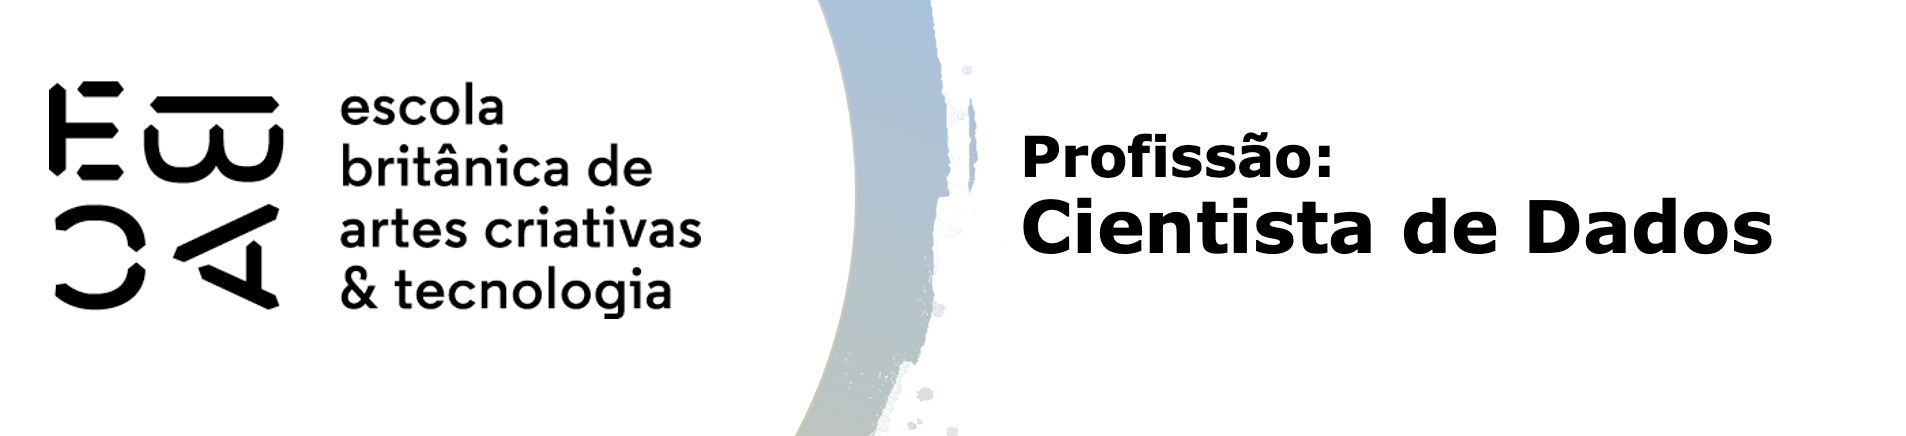

# Tarefa

In [28]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.stats.weightstats import ttest_ind
from scipy.stats import t as t_dist  


In [29]:
pg = sns.load_dataset('penguins')

In [30]:
pg.groupby('sex')['body_mass_g'].describe()

,count,mean,std,min,25%,50%,75%,max
sex,,,,,,,,
Female,165.0,3862.272727,666.172050,2700.0,3350.0,3650.0,4550.0,5200.0
Male,168.0,4545.684524,787.628884,3250.0,3900.0,4300.0,5312.5,6300.0


<Axes: xlabel='sex', ylabel='body_mass_g'>

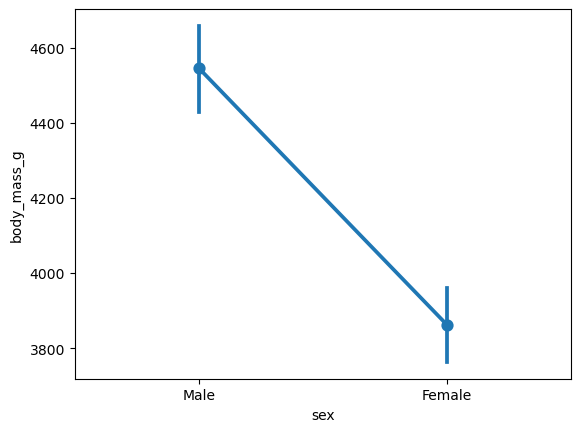

In [31]:
sns.pointplot(data=pg, x='sex', y = 'body_mass_g')

## 1) Diferença de peso entre machos e fêmeas

Na base de pinguins, podemos ver que há diferença de peso entre machos e fêmeas. Mas será que é uma conclusão extrapolável a toda a população de pinguins? Assumindo que essa amostra é aleatória e representativa da população de pinguins, realize um teste T com 5% de significância para verificar se podemos induzir esta conclusão para a população toda.

In [32]:
# Seleciona os pesos dos pinguins machos
x_1 = pg.loc[pg['sex'] == 'Male', 'body_mass_g']

# Seleciona os pesos dos pinguins fêmeas
x_2 = pg.loc[pg['sex'] == 'Female', 'body_mass_g']

# Realiza o teste t para duas amostras independentes, testando se a média dos machos é maior que a das fêmeas
teste_t = ttest_ind(x_1, x_2, alternative='larger', usevar='pooled', value=0)

# Exibe o resultado do teste t
teste_t

(8.541720337994514, 2.4486233757981297e-16, 331.0)

In [33]:
print(f'Estatística do teste: {teste_t[0]:.2f}')
print(f'             P-value: {teste_t[1]:.4f}')
print(f'  Graus de liberdade: {teste_t[2]:.2f}')

Estatística do teste: 8.54
             P-value: 0.0000
  Graus de liberdade: 331.00


## 2) (opcional) Representação gráfica do teste

Siga os passos da aula para você poder visualizar a estatística do teste, sua distribuição e a região crítica do teste.

In [34]:
t_stat = 8.54
graus_de_liberdade = 331
alpha = 0.05

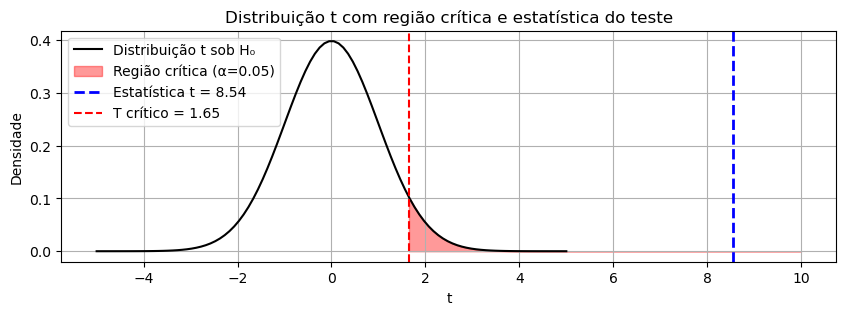

In [35]:
# Define a média e variância da distribuição t (para visualização)
mu = 0 
variance = 1
sigma = variance ** .5

# Cria um vetor de valores de t para o eixo x, centrado na média
x0 = np.linspace(mu - 5*sigma, mu + 5*sigma, 100)

# Calcula a densidade da distribuição t para cada valor de x0
y = t_dist.pdf(x0, graus_de_liberdade)

# Calcula o valor crítico de t para o nível de significância escolhido (região de rejeição à direita)
t_critico = t_dist.ppf(1 - alpha, graus_de_liberdade)

# Plota a curva da distribuição t
plt.figure(figsize=(10,3))
plt.plot(x0, y, label='Distribuição t sob H₀', color='black')

# Destaca a região crítica (onde rejeitamos H₀)
x_rejeita = np.linspace(t_critico, 10, 300)
plt.fill_between(x_rejeita, t_dist.pdf(x_rejeita, graus_de_liberdade), color='red', alpha=0.4, label='Região crítica (α=0.05)')

# Traça uma linha vertical na estatística t observada
plt.axvline(t_stat, color='blue', linestyle='--', lw=2, label=f'Estatística t = {t_stat:.2f}')

# Traça uma linha vertical no valor crítico de t
plt.axvline(t_critico, color='red', linestyle='--', label=f'T crítico = {t_critico:.2f}')

# Ajusta título, rótulos e legenda do gráfico
plt.title('Distribuição t com região crítica e estatística do teste')
plt.xlabel('t')
plt.ylabel('Densidade')
plt.legend()
plt.grid(True)
plt.show()

## 3) Considere as espécies

Repita o exercício I, uma vez para cada espécie de pinguim. Qual é o *p-value* associado a cada raça?

In [36]:
pg.species.unique()

array(['Adelie', 'Chinstrap', 'Gentoo'], dtype=object)

In [37]:
pg_adelie = pg.loc[pg.species == 'Adelie']
pg_chinstrap = pg.loc[pg.species == 'Chinstrap']
pg_gentoo = pg.loc[pg.species == 'Gentoo']

In [38]:
def diferenca_de_massas(df):
    # Seleciona os pesos dos pinguins machos
    _x_1 = df.loc[df['sex'] == 'Male', 'body_mass_g'].dropna()

    # Seleciona os pesos dos pinguins fêmeas
    _x_2 = df.loc[df['sex'] == 'Female', 'body_mass_g'].dropna()

    # Realiza o teste t para duas amostras independentes, testando se a média dos machos é maior que a das fêmeas
    teste_t = ttest_ind(_x_1, _x_2, alternative='larger', usevar='pooled', value=0)
    
    print(f'Estatística do teste: {teste_t[0]:.2f}')
    print(f'             P-value: {teste_t[1]:.4f}')
    print(f'  Graus de liberdade: {teste_t[2]:.2f}')
    
    return teste_t

In [ ]:
# from pingouin import ttest

# def diferenca_de_massas(df):
#     x_male = df.loc[df['sex'] == 'Male', 'body_mass_g'].dropna()
#     x_female = df.loc[df['sex'] == 'Female', 'body_mass_g'].dropna()
    
#     if len(x_male) < 2 or len(x_female) < 2:
#         print("Dados insuficientes para o teste t.")
#         return None

#     teste_t = ttest(x_male, x_female, alternative='greater', paired=False)

#     print(f'Estatística do teste: {teste_t["T"].values[0]:.2f}')
#     print(f'             P-value: {teste_t["p-val"].values[0]:.4f}')
#     print(f'  Graus de liberdade: {teste_t["dof"].values[0]:.2f}')
    
#     return teste_t




In [43]:
print('Pinguins da raça Adelie')
diferenca_de_massas(pg_adelie)
print('---')
print('Pinguins da raça Chinstrap')
diferenca_de_massas(pg_chinstrap)
print('---')
print('Pinguins da raça Gentoo')
diferenca_de_massas(pg_gentoo)

Pinguins da raça Adelie
Estatística do teste: 13.13
             P-value: 0.0000
  Graus de liberdade: 144.00
---
Pinguins da raça Chinstrap
Estatística do teste: 5.21
             P-value: 0.0000
  Graus de liberdade: 66.00
---
Pinguins da raça Gentoo
Estatística do teste: 14.72
             P-value: 0.0000
  Graus de liberdade: 117.00


(14.721676481405709, 1.066843801009443e-28, 117.0)

In [58]:
def plotagem_da_estatistica_t( _t_stat,_graus_de_liberdade,_alpha = 0.05):
    mu =0
    variance=1
    sigma = variance**.5
    
    x = np.linspace(mu- 5*sigma, mu + 5*sigma, 100)
    
    y = t_dist.pdf(x, _graus_de_liberdade)
    
    t_critico= (t_dist.ppf(1 - _alpha, _graus_de_liberdade))
    
    plt.figure(figsize=(10,3))
    plt.plot(x,y,label='Distribuição t sob H₀', color='black')
    
    x_rejeita = np.linspace(t_critico, 10, 300)
    plt.fill_between(x_rejeita, t_dist.pdf(x_rejeita, _graus_de_liberdade), color='red', alpha =0.4, label='Região crítica (α=0.05)')
    
    plt.axvline(_t_stat, color='blue', linestyle='--', label=f'T crítico = {t_critico:.2f}')
    
    plt.title('Distribuição t com região crítica e estatística do teste')
    plt.xlabel('t')
    plt.ylabel('Densidade')
    plt.legend()
    plt.grid(True)
    plt.show()

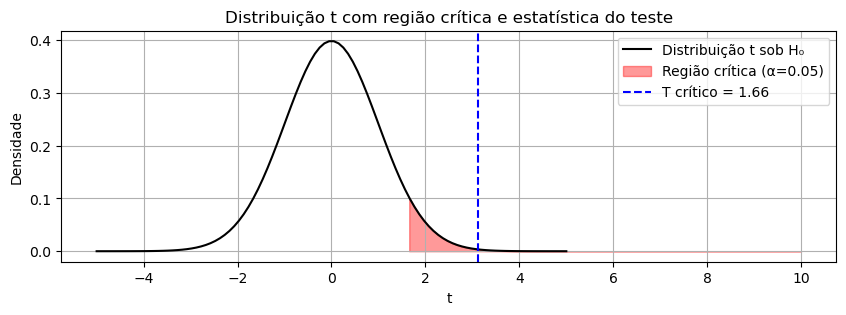

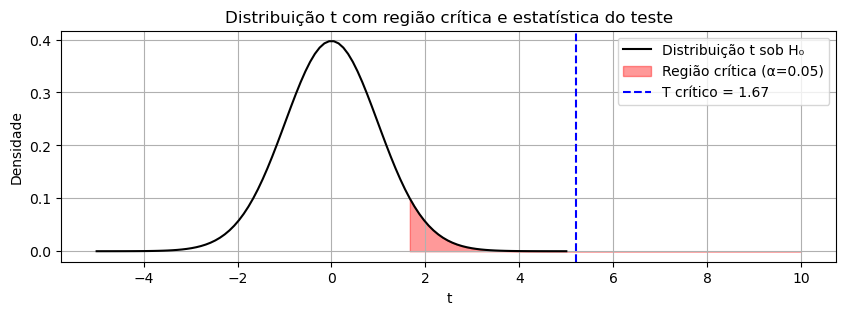

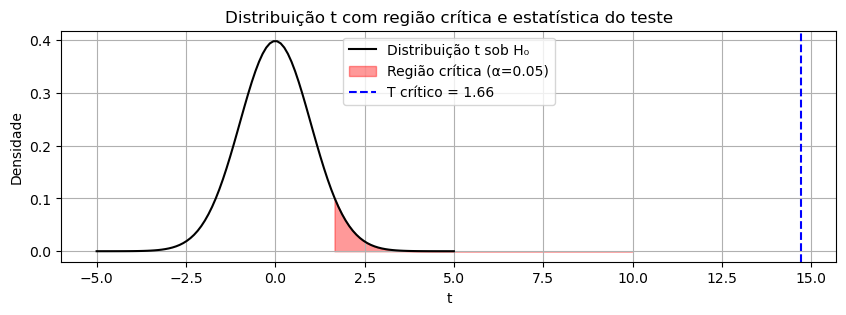

In [59]:
plotagem_da_estatistica_t(_t_stat=3.13,_graus_de_liberdade=144)
plotagem_da_estatistica_t(_t_stat = 5.21,_graus_de_liberdade=66)
plotagem_da_estatistica_t(_t_stat = 14.72,_graus_de_liberdade=117)
